In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Sleep_disorder_data.csv")

In [4]:
df.head(15)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [8]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [9]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [10]:
df['Sleep Disorder'].fillna('None',inplace=True)

In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df[['Systolic_BP','Diastolic_BP']] = df['Blood Pressure'].str.split('/',expand = True)

In [13]:
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')

In [14]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [15]:
df.drop(columns=["Blood Pressure"], inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    object 
 12  Systolic_BP              374 non-null    int64  
 13  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(9), o

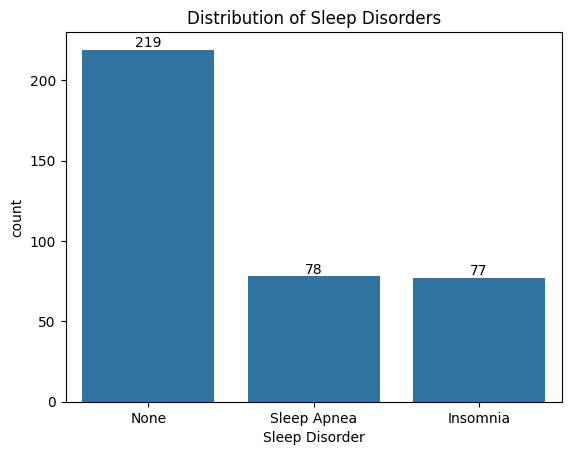

In [17]:
#Charuta
# 1. What is the correlation between health-related features?
ax = sns.countplot(data=df, x='Sleep Disorder')
ax.bar_label(ax.containers[0])
ax.set_title("Distribution of Sleep Disorders")
plt.show()

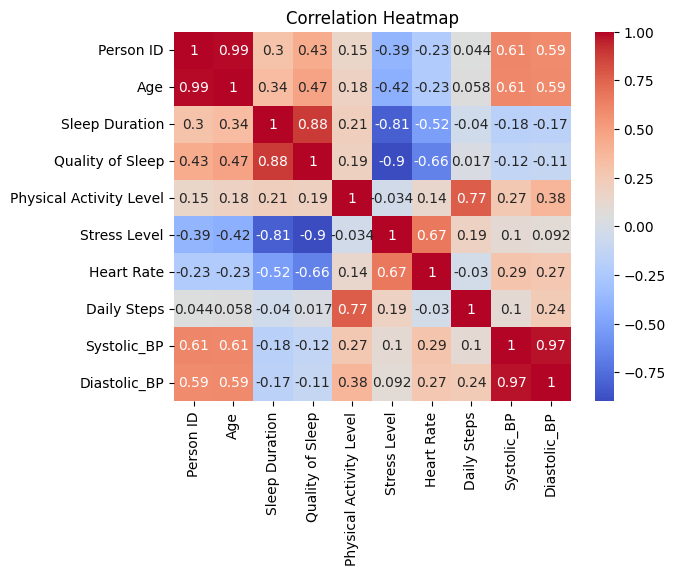

In [18]:
# 2. What is the distribution of different sleep disorders in the dataset?

correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

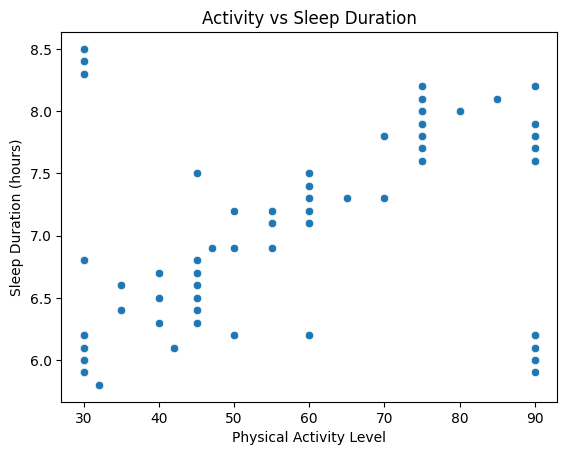

In [19]:
#Vaishnavi
# 3. Relationship between Physical Activity and Sleep Duration.

sns.scatterplot(x='Physical Activity Level', y='Sleep Duration', data=df)
plt.title('Activity vs Sleep Duration')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Duration (hours)')
plt.show()

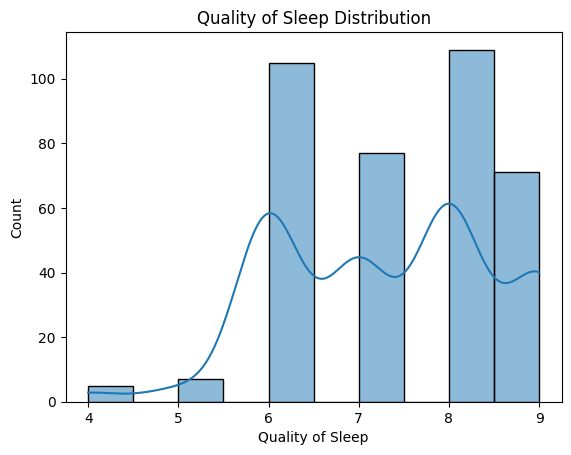

In [20]:
# 4.How is the Quality of Sleep distributed?

sns.histplot(df['Quality of Sleep'], kde=True)
plt.title('Quality of Sleep Distribution')
plt.show()

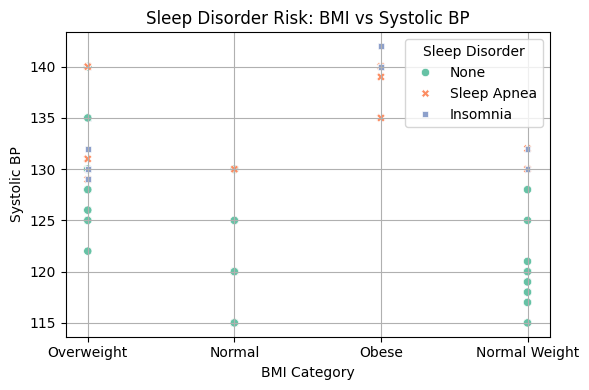

In [24]:
#Tanuja
#5.Can we predict sleep disorder risk using BMI and BP?

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df,x='BMI Category',y='Systolic_BP', hue='Sleep Disorder', style='Sleep Disorder',palette='Set2')
plt.title('Sleep Disorder Risk: BMI vs Systolic BP')
plt.xlabel('BMI Category')
plt.ylabel('Systolic BP')
plt.grid(True)
plt.tight_layout()
plt.show()

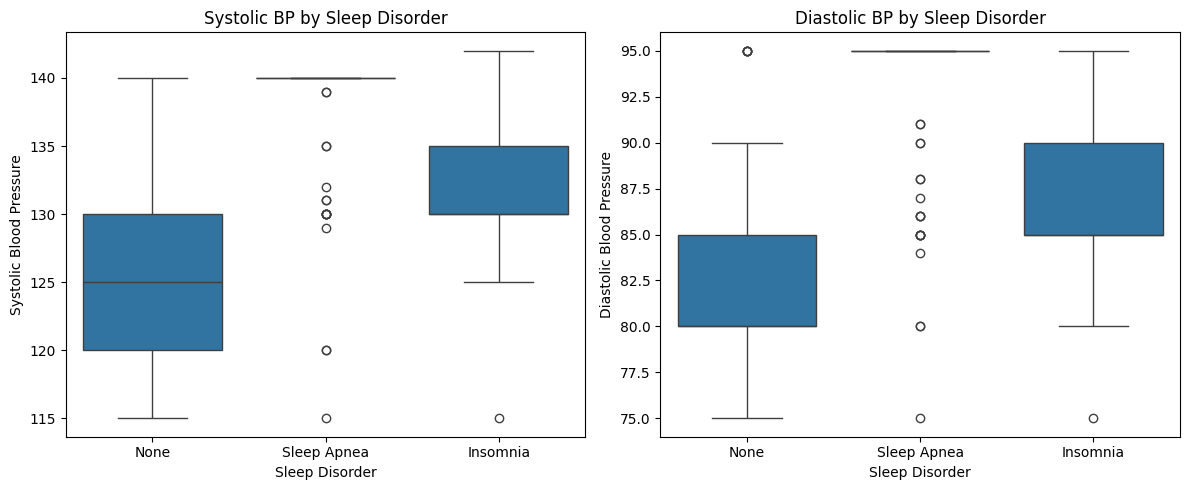

In [25]:
#Tanuja
#6. What is the relationship between sleep disorder and blood pressure

plt.figure(figsize=(12, 5))

# Boxplot: Systolic BP vs Sleep Disorder
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Sleep Disorder', y='Systolic_BP')
plt.title('Systolic BP by Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Systolic Blood Pressure')

# Boxplot: Diastolic BP vs Sleep Disorder
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Sleep Disorder', y='Diastolic_BP')
plt.title('Diastolic BP by Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Diastolic Blood Pressure')

plt.tight_layout()
plt.show()

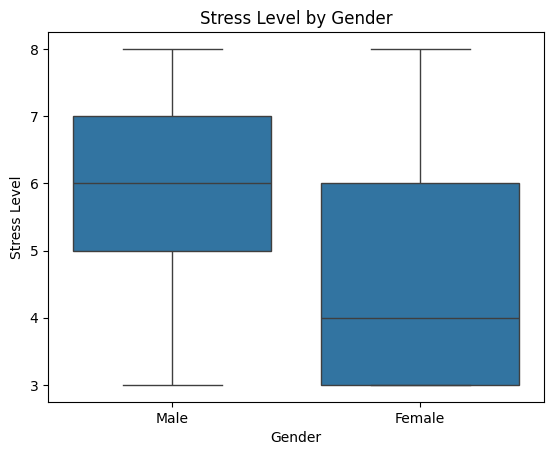

In [21]:
#Arya
#7. How does Stress Level vary by Gender?

sns.boxplot(x='Gender', y='Stress Level', data=df)
plt.title('Stress Level by Gender')
plt.show()

In [22]:
#8. IQR of sleep duration for insomnia patients

q1 = df[df['Sleep Disorder'] == 'Insomnia']['Sleep Duration'].quantile(0.25)
q3 = df[df['Sleep Disorder'] == 'Insomnia']['Sleep Duration'].quantile(0.75)
iqr = q3 - q1
print("IQR for Insomnia Sleep Duration:", iqr)

IQR for Insomnia Sleep Duration: 0.1999999999999993


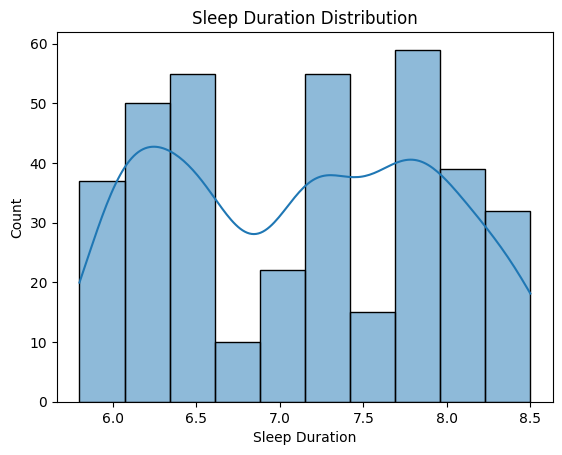

In [34]:
#Kumud
#9. What is the distribution of sleep duration
sns.histplot(df['Sleep Duration'], kde=True)
plt.title('Sleep Duration Distribution')
plt.show()

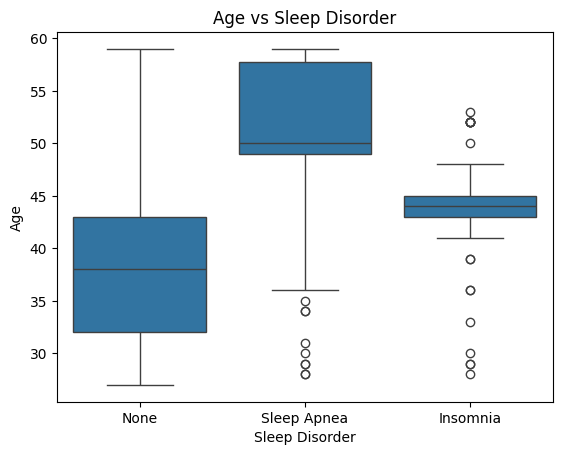

In [27]:
#Saniya
#11. Is there a relationship between age and sleep disorder?

sns.boxplot(x="Sleep Disorder", y="Age", data=df)
plt.title("Age vs Sleep Disorder")
plt.show()



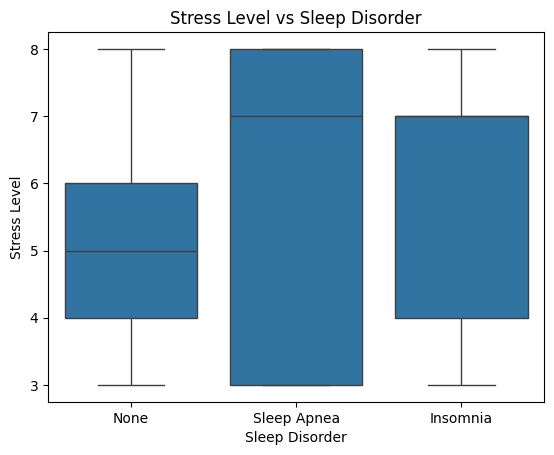

In [28]:
#12. Do people with higher stress levels tend to have sleep disorders?

sns.boxplot(x="Sleep Disorder", y="Stress Level", data=df)
plt.title("Stress Level vs Sleep Disorder")
plt.show()

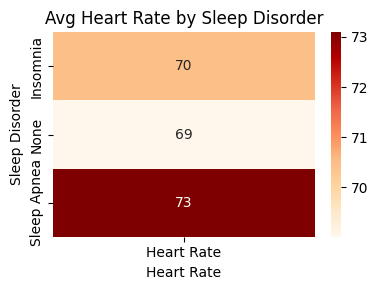

In [29]:
#Bhumi
#13. Group by Sleep Disorder and calculate average Heart Rate
avg_hr = df.groupby('Sleep Disorder')[['Heart Rate']].mean()

# Plot heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(avg_hr, annot=True, cmap='OrRd')
plt.title("Avg Heart Rate by Sleep Disorder")
plt.ylabel("Sleep Disorder")
plt.xlabel("Heart Rate")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

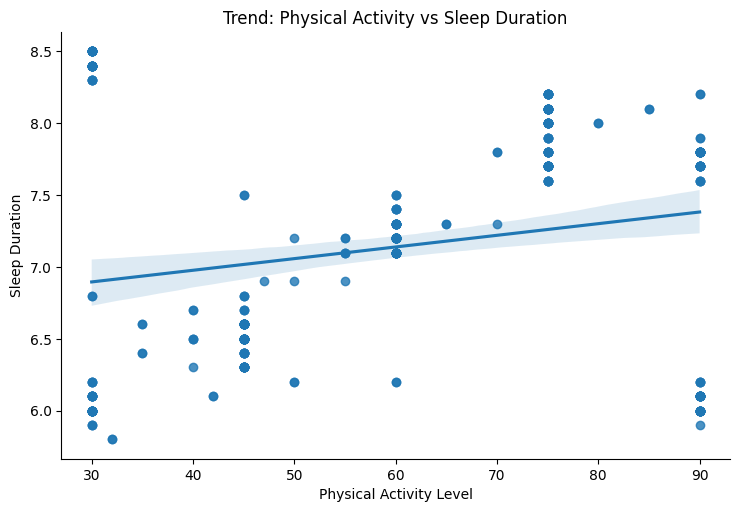

In [33]:
#14. "Does being more active during the day help you sleep better at night?"
plt.figure(figsize=(8, 5))
sns.lmplot(x='Physical Activity Level', y='Sleep Duration', data=df, aspect=1.5)
plt.title('Trend: Physical Activity vs Sleep Duration')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Duration')
plt.show()
